# Predicting Residential EV Charging Loads using Neural Networks

- [View Solution Notebook](./solutions.html)
- [View Project Page](https://www.codecademy.com/)

In [117]:
# Setup - import basic data libraries
import numpy as np
import os
import pandas as pd
import sys

## Task Group 1 - Load, Inspect, and Merge Datasets

### Task 1

The file `'datasets/EV charging reports.csv'` contains electric vehicle (EV) charging data. These come from various residential apartment buildings in Norway. The data includes specific user and garage information, plug-in and plug-out times, charging loads, and the dates of the charging sessions.

Import this CSV file to a pandas DataFrame named `ev_charging_reports`.

Use the `.head()` method to preview the first five rows.

In [11]:
os.getcwd()
os.listdir()

['Predicting Electric Vehicle Charging Loads.ipynb',
 'Dataset 1_EV charging reports.csv',
 'jbks2rcwyj-1.zip',
 'Dataset 3b_Hourly EV loads - Aggregated shared.csv',
 'Dataset 5_AMS data from garage Bl2.csv',
 'Dataset 2_Hourly EV loads - Per user.csv',
 'Dataset 3a_Hourly EV loads - Aggregated private.csv',
 'Dataset 6_Local traffic distribution.csv',
 '.gitignore',
 '.git',
 'README.md',
 '.ipynb_checkpoints']

In [118]:
print(sys.executable)

/home/anchang/miniforge3/bin/python3


In [10]:
ev_charging_reports = pd.read_csv("Dataset 1_EV charging reports.csv", sep=";")
ev_charging_reports.head()

,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Plugin_category,Duration_category
0,1,AdO3,AdO3-4,Private,NaN,21.12.2018 10:20,10,21.12.2018 10:23,10.0,"0,3","0,05",Dec,Friday,late morning (9-12),Less than 3 hours
1,2,AdO3,AdO3-4,Private,NaN,21.12.2018 10:24,10,21.12.2018 10:32,10.0,"0,87","0,136666667",Dec,Friday,late morning (9-12),Less than 3 hours
2,3,AdO3,AdO3-4,Private,NaN,21.12.2018 11:33,11,21.12.2018 19:46,19.0,"29,87","8,216388889",Dec,Friday,late morning (9-12),Between 6 and 9 hours
3,4,AdO3,AdO3-2,Private,NaN,22.12.2018 16:15,16,23.12.2018 16:40,16.0,"15,56","24,41972222",Dec,Saturday,late afternoon (15-18),More than 18 hours
4,5,AdO3,AdO3-2,Private,NaN,24.12.2018 22:03,22,24.12.2018 23:02,23.0,"3,62","0,970555556",Dec,Monday,late evening (21-midnight),Less than 3 hours


In [13]:
ev_charging_reports.columns

Index(['session_ID', 'Garage_ID', 'User_ID', 'User_type', 'Shared_ID',
       'Start_plugin', 'Start_plugin_hour', 'End_plugout', 'End_plugout_hour',
       'El_kWh', 'Duration_hours', 'month_plugin', 'weekdays_plugin',
       'Plugin_category', 'Duration_category'],
      dtype='object')

In [14]:
ev_charging_reports.shape

(6878, 15)

<details><summary style="display:list-item; font-size:16px; color:blue;">What is the structure of the dataset?</summary>

- **session_ID** - the unique id for each EV charging session
- **Garage_ID** - the unique id for the garage of the apartment
- **User_ID** - the unique id for each user
- **User_private** - 1.0 indicates private charge point spaces and 0.0 indicates shared charge point spaces
- **Shared_ID** - the unique id if shared charge point spaces are used
- **Start_plugin** - the plug-in date and time in the format (day.month.year hour:minute)
- **Start_plugin_hour** - the plug-in date and time rounded to the start of the hour
- **End_plugout** - the plug-out date and time in the format (day.month.year hour:minute)
- **End_plugout_hour** - the start of the hour of the `End_plugout` hour
- **El_kWh** - the charged energy in kWh (charging loads)
- **Duration_hours** - the duration of the EV connection time per session
- **Plugin_category** - the plug-in time categorized by early/late night, morning, afternoon, and evening
- **Duration_category** - the plug-in duration categorized by 3 hour groups
- **month_plugin_{month}** - the month of the plug-in session
- **weekdays_plugin_{day}** - the day of the week of the plug-in session

### Task 2

Import the file `'datasets/Local traffic distribution.csv'` to a pandas DataFrame named `traffic_reports`. This dataset contains the hourly local traffic density counts at 5 nearby traffic locations. 

Preview the first five rows.

In [12]:
traffic_reports = pd.read_csv("Dataset 3a_Hourly EV loads - Aggregated private.csv", sep=";")
traffic_reports.head()

,date_from,daily_hour,weekday,month,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
0,21.12.2018 10:00,10,Friday,Dec,"1,17","1,17",0,"0,174",1
1,21.12.2018 11:00,11,Friday,Dec,"1,62","3,24",0,0,1
2,21.12.2018 12:00,12,Friday,Dec,"3,6","7,2",0,0,1
3,21.12.2018 13:00,13,Friday,Dec,"3,6","7,2",0,0,1
4,21.12.2018 14:00,14,Friday,Dec,"3,6","7,2",0,0,1


In [15]:
traffic_reports.columns

Index(['date_from', 'daily_hour', 'weekday', 'month', 'Synthetic_3_6kW',
       'Synthetic_7_2kW', 'Flex_3_6kW', 'Flex_7_2kW', 'n_private'],
      dtype='object')

In [16]:
traffic_reports.shape

(9757, 9)

<details><summary style="display:list-item; font-size:16px; color:blue;">What is the structure of the dataset?</summary>

- **Date_from** - the starting time in the format (day.month.year hour:minute)
- **Date_to** - the ending time in the format (day.month.year hour:minute)
- **Location 1 to 5** - contains the number of vehicles each hour at a specified traffic location.


### Task 3

We'd like to use the traffic data to help our model. The same charging location may charge at different rates depending on the number of cars being charged, so this traffic data might help the model out.

Merge the `ev_charging_reports` and `traffic_reports` datasets together into a Dataframe named `ev_charging_traffic` using the columns:

- `Start_plugin_hour` in `ev_charging_reports`
- `Date_from` in `traffic_reports`

In [22]:
print(ev_charging_reports["Start_plugin_hour"].dtype)
print(ev_charging_reports["Start_plugin"].dtype)
print(traffic_reports["date_from"].dtype)
print(traffic_reports["date_from"].head())

int64
object
object
0    21.12.2018 10:00
1    21.12.2018 11:00
2    21.12.2018 12:00
3    21.12.2018 13:00
4    21.12.2018 14:00
Name: date_from, dtype: object


In [46]:
ev_charging_traffic = ev_charging_reports.merge(traffic_reports, left_on="Start_plugin", right_on="date_from")
ev_charging_traffic.head()

,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,...,Duration_category,date_from,daily_hour,weekday,month,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
0,13,AdO3,AdO3-2,Private,NaN,30.12.2018 22:00,22,31.12.2018 11:28,11.0,"9,79",...,Between 12 and 15 hours,30.12.2018 22:00,22,Sunday,Dec,"3,6","7,2",0,0,2
1,59,AsO2,Share-6,Shared,Shared-5,18.01.2019 02:00,2,18.01.2019 02:08,2.0,"0,75",...,Less than 3 hours,18.01.2019 02:00,2,Friday,Jan,"0,14",0,"7,06","14,4",5
2,74,Bl2,Bl2-4,Private,NaN,23.01.2019 19:00,19,24.01.2019 05:17,5.0,"15,66",...,Between 9 and 12 hours,23.01.2019 19:00,19,Wednesday,Jan,"3,6","7,2","3,6","7,2",5
3,95,Bl2,Bl2-1,Private,NaN,27.01.2019 04:00,4,27.01.2019 09:53,9.0,"0,94",...,Between 3 and 6 hours,27.01.2019 04:00,4,Sunday,Jan,"0,94","0,94","7,234","14,468",6
4,101,UT9,Share-14,Shared,Shared-12,28.01.2019 11:00,11,28.01.2019 13:54,13.0,"10,64",...,Less than 3 hours,28.01.2019 11:00,11,Monday,Jan,0,0,"3,6","7,2",6


### Task 4

Use `.info()` to inspect the merged dataset. Specifically, pay attention to the data types and number of missing values in each column.

In [47]:
ev_charging_traffic.shape

(112, 24)

In [48]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   session_ID         112 non-null    int64  
 1   Garage_ID          112 non-null    object 
 2   User_ID            112 non-null    object 
 3   User_type          112 non-null    object 
 4   Shared_ID          17 non-null     object 
 5   Start_plugin       112 non-null    object 
 6   Start_plugin_hour  112 non-null    int64  
 7   End_plugout        112 non-null    object 
 8   End_plugout_hour   112 non-null    float64
 9   El_kWh             112 non-null    object 
 10  Duration_hours     112 non-null    object 
 11  month_plugin       112 non-null    object 
 12  weekdays_plugin    112 non-null    object 
 13  Plugin_category    112 non-null    object 
 14  Duration_category  112 non-null    object 
 15  date_from          112 non-null    object 
 16  daily_hour         112 non

<details><summary style="display:list-item; font-size:16px; color:blue;">What do we notice about merged dataset under inspection?</summary>

We see that there are 39 columns and 6,833 rows in our merged dataset.

Some notable things we might have to address:

- We expected columns like `El_kWh` and `Duration_hours` to be floats but they are actually object data types.

- There are many identifying columns like `session_ID` and `User_ID` that might not be useful for training.

## Task Group 2 - Data Cleaning and Preparation

### Task 5

Let's start by reducing the size of our dataset by dropping columns that won't be used for training. These include
- ID columns
- columns with lots of missing data
- non-numeric columns (for now, since we haven't yet covered using non-numeric data in neural networks)

Drop columns you don't want to use in training from `ev_charging_traffic`.

To match our solution, drop the columns

```py
['session_ID', 'Garage_ID', 'User_ID', 
                'Shared_ID',
                'Plugin_category','Duration_category', 
                'Start_plugin', 'Start_plugin_hour', 'End_plugout', 'End_plugout_hour', 
                'Date_from', 'Date_to']
```

In [49]:
columns_to_drop = [
    "session_ID",
    "Garage_ID",
    "User_ID",
    "Shared_ID",
    "Plugin_category",
    "Duration_category",
    "Start_plugin",
    "Start_plugin_hour",
    "End_plugout",
    "End_plugout_hour",
    "date_from"
]
ev_charging_traffic = ev_charging_traffic.drop(columns_to_drop, axis=1)
ev_charging_traffic.shape

(112, 13)

In [50]:
ev_charging_traffic.head()

,User_type,El_kWh,Duration_hours,month_plugin,weekdays_plugin,daily_hour,weekday,month,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
0,Private,"9,79","13,45472222",Dec,Sunday,22,Sunday,Dec,"3,6","7,2",0,0,2
1,Shared,"0,75","0,1325",Jan,Friday,2,Friday,Jan,"0,14",0,"7,06","14,4",5
2,Private,"15,66","10,28333333",Jan,Wednesday,19,Wednesday,Jan,"3,6","7,2","3,6","7,2",5
3,Private,"0,94","5,880833333",Jan,Sunday,4,Sunday,Jan,"0,94","0,94","7,234","14,468",6
4,Shared,"10,64","2,9025",Jan,Monday,11,Monday,Jan,0,0,"3,6","7,2",6


In [51]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User_type        112 non-null    object
 1   El_kWh           112 non-null    object
 2   Duration_hours   112 non-null    object
 3   month_plugin     112 non-null    object
 4   weekdays_plugin  112 non-null    object
 5   daily_hour       112 non-null    int64 
 6   weekday          112 non-null    object
 7   month            112 non-null    object
 8   Synthetic_3_6kW  112 non-null    object
 9   Synthetic_7_2kW  112 non-null    object
 10  Flex_3_6kW       112 non-null    object
 11  Flex_7_2kW       112 non-null    object
 12  n_private        112 non-null    int64 
dtypes: int64(2), object(11)
memory usage: 11.5+ KB


### Task 6

Earlier we saw that the `El_kWh` and `Duration_hours` columns were object data types. Upon further inspection, we see that the reason is that the data is following European notation where commas `,` are used as decimals instead of periods.

Replace `,` with `.` in these three columns.

In [53]:
ev_charging_traffic["El_kWh"] = (ev_charging_traffic["El_kWh"].str.replace(",", ".", regex=False))
ev_charging_traffic["Duration_hours"] = (ev_charging_traffic["Duration_hours"].str.replace(",", ".", regex=False))

In [55]:
kw=["Synthetic_3_6kW", "Synthetic_7_2kW", "Flex_3_6kW", "Flex_7_2kW"]
ev_charging_traffic[kw] = ev_charging_traffic[kw].apply(
    lambda col: col.str.replace(",", ".", regex=False)
)

In [56]:
ev_charging_traffic[kw] = ev_charging_traffic[kw].apply(pd.to_numeric)

In [57]:
ev_charging_traffic.dtypes

User_type           object
El_kWh              object
Duration_hours      object
month_plugin        object
weekdays_plugin     object
daily_hour           int64
weekday             object
month               object
Synthetic_3_6kW    float64
Synthetic_7_2kW    float64
Flex_3_6kW         float64
Flex_7_2kW         float64
n_private            int64
dtype: object

In [58]:
ev_charging_traffic.head()

,User_type,El_kWh,Duration_hours,month_plugin,weekdays_plugin,daily_hour,weekday,month,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
0,Private,9.79,13.45472222,Dec,Sunday,22,Sunday,Dec,3.60,7.20,0.000,0.000,2
1,Shared,0.75,0.1325,Jan,Friday,2,Friday,Jan,0.14,0.00,7.060,14.400,5
2,Private,15.66,10.28333333,Jan,Wednesday,19,Wednesday,Jan,3.60,7.20,3.600,7.200,5
3,Private,0.94,5.880833333,Jan,Sunday,4,Sunday,Jan,0.94,0.94,7.234,14.468,6
4,Shared,10.64,2.9025,Jan,Monday,11,Monday,Jan,0.00,0.00,3.600,7.200,6


### Task 7

Next, convert the data types of all the columns of `ev_charging_traffic` to floats.

In [59]:
ev_charging_traffic["El_kWh"] = ev_charging_traffic["El_kWh"].astype(float)
ev_charging_traffic["Duration_hours"] = ev_charging_traffic["Duration_hours"].astype(float)
ev_charging_traffic["Duration_hours"] = ev_charging_traffic["Duration_hours"].astype(float)

In [60]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_type        112 non-null    object 
 1   El_kWh           112 non-null    float64
 2   Duration_hours   112 non-null    float64
 3   month_plugin     112 non-null    object 
 4   weekdays_plugin  112 non-null    object 
 5   daily_hour       112 non-null    int64  
 6   weekday          112 non-null    object 
 7   month            112 non-null    object 
 8   Synthetic_3_6kW  112 non-null    float64
 9   Synthetic_7_2kW  112 non-null    float64
 10  Flex_3_6kW       112 non-null    float64
 11  Flex_7_2kW       112 non-null    float64
 12  n_private        112 non-null    int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 11.5+ KB


In [61]:
print(ev_charging_traffic.dtypes)
print(ev_charging_traffic.isna().sum())
print(ev_charging_traffic.shape)

User_type           object
El_kWh             float64
Duration_hours     float64
month_plugin        object
weekdays_plugin     object
daily_hour           int64
weekday             object
month               object
Synthetic_3_6kW    float64
Synthetic_7_2kW    float64
Flex_3_6kW         float64
Flex_7_2kW         float64
n_private            int64
dtype: object
User_type          0
El_kWh             0
Duration_hours     0
month_plugin       0
weekdays_plugin    0
daily_hour         0
weekday            0
month              0
Synthetic_3_6kW    0
Synthetic_7_2kW    0
Flex_3_6kW         0
Flex_7_2kW         0
n_private          0
dtype: int64
(112, 13)


In [62]:
ev_charging_traffic.describe()

,El_kWh,Duration_hours,daily_hour,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,10.748125,14.821744,16.294643,17.455982,21.934018,20.299286,54.210768,35.428571
std,10.273770,26.761260,4.781041,12.298528,16.085114,17.831745,43.155104,17.101032
min,0.010000,0.010833,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,4.092500,2.456389,15.000000,7.200000,8.782500,5.479250,17.142500,17.750000
50%,8.580000,9.704722,17.000000,14.740000,20.240000,17.581500,49.865000,42.500000
75%,13.277500,17.374653,19.250000,26.047500,31.892500,29.780750,74.667500,48.000000
max,71.600000,239.240278,23.000000,52.990000,69.470000,73.030000,171.560000,58.000000


In [67]:
ev_charging_traffic.select_dtypes(exclude="number").columns

Index(['User_type', 'month_plugin', 'weekdays_plugin', 'weekday', 'month'], dtype='object')

## Task Group 3 - Train Test Split

Next, let's split the dataset into training and testing datasets. 

The training data will be used to train the model and the testing data will be used to evaluate the model.

### Task 8

First, create two datasets from `ev_charging_traffic`:

- `X` contains only the input numerical features
- `y` contains only the target column `El_kWh`

In [96]:
X = ev_charging_traffic.select_dtypes(include="number").drop(columns = ["El_kWh"])

In [97]:
y = ev_charging_traffic[["El_kWh"]]

### Task 9

Use `sklearn` to split `X` and `y` into training and testing datasets. The training set should use 80% of the data. Set the `random_state` parameter to `2`.

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
train_size = 0.8
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= train_size, test_size = test_size, random_state=2)

In [100]:
X_train.describe()

,Duration_hours,daily_hour,Synthetic_3_6kW,Synthetic_7_2kW,Flex_3_6kW,Flex_7_2kW,n_private
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,15.426261,16.505618,19.583371,24.648876,22.684888,60.923730,38.224719
std,27.721413,4.826827,12.411363,16.338091,18.742288,44.747079,16.377474
min,0.010833,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,2.750833,15.000000,10.380000,11.400000,7.200000,21.600000,23.000000
50%,9.791389,17.000000,18.060000,22.280000,19.710000,56.130000,46.000000
75%,17.710278,20.000000,28.900000,34.680000,33.130000,92.130000,49.000000
max,239.240278,23.000000,52.990000,69.470000,73.030000,171.560000,58.000000


## Task Group 4 - Linear Regression Baseline

This section is optional, but useful. The idea is to compare our neural network to a basic linear regression. After all, if a basic linear regression works just as well, there's no need for the neural network!

If you haven't done linear regression with scikit-learn before, feel free to use [our solution code](./solutions.html) or to skip ahead.

### Task 10

Use Scikit-learn to train a Linear Regression model using the training data to predict EV charging loads.

The linear regression will be used as a baseline to compare against the neural network we will train later.

In [101]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 7)","[[ 0.04,-0.16, 0.23,..., 0.15,-0.11,-0.02]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Duration_hours','daily_hour','Synthetic_3_6kW',...,'Flex_3_6kW', 'Flex_7_2kW','n_private']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[14.34]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


### Task 11

Evaluate the linear regression baseline by calculating the MSE on the testing data. Use `mean_squared_error` from `sklearn.metrics`.

Save the testing MSE to the variable `test_mse` and print it out.

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred = linear_model.predict(X_test)
test_mse =  mean_squared_error(pred, y_test)
RMSE = np.sqrt(test_mse)
MAE = mean_absolute_error(pred, y_test)

print(f"test test_mse: {test_mse:.6f}")
print(f"test rmse: {RMSE:.6f}")
print(f"test mae: {MAE:.6f}")

test test_mse: 93.915920
test rmse: 9.691023
test mae: 7.638382


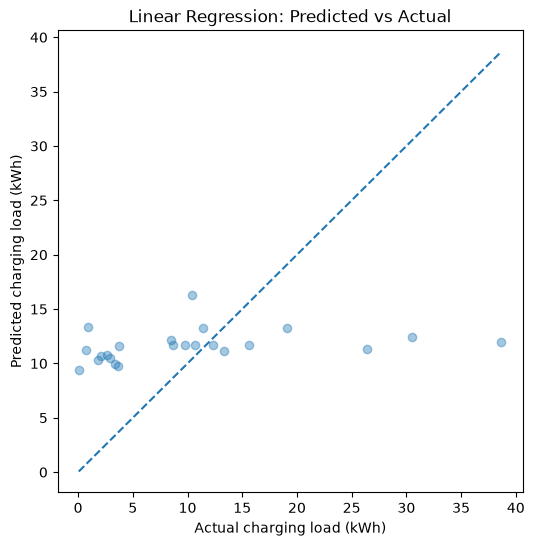

In [105]:
import numpy as np
import matplotlib.pyplot as plt

y_test_plot = np.asarray(y_test).ravel()
pred_plot = np.asarray(pred).ravel()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, pred_plot, alpha=0.4)

minimum = min(y_test_plot.min(), pred_plot.min())
maximum = max(y_test_plot.max(), pred_plot.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual charging load (kWh)")
plt.ylabel("Predicted charging load (kWh)")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

Looks like our mean squared error is around `131.4` (if you used different columns in your model than we did, you might have a different value). Remember, this is squared error. If we take the square root, we have about `11.5`. One way of interpreting this is to say that the linear regression, on average, is off by `11.5 kWh`.

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [112]:
import pandas as pd

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [113]:
print(X_train_scaled.mean().round(2))
print(X_train_scaled.std().round(2))

Duration_hours    -0.0
daily_hour         0.0
Synthetic_3_6kW    0.0
Synthetic_7_2kW    0.0
Flex_3_6kW        -0.0
Flex_7_2kW         0.0
n_private         -0.0
dtype: float64
Duration_hours     1.01
daily_hour         1.01
Synthetic_3_6kW    1.01
Synthetic_7_2kW    1.01
Flex_3_6kW         1.01
Flex_7_2kW         1.01
n_private          1.01
dtype: float64


## Task Group 5 - Train a Neural Network Using PyTorch

Let's now create a neural network using PyTorch to predict EV charging loads.

### Task 12

First, we'll need to import the PyTorch library and modules.

Import the PyTorch library `torch`.

From `torch`, import `nn` to access built-in code for constructing networks and defining loss functions.

From `torch`, import `optim` to access built-in optimizer algorithms.

In [116]:
import torch

ModuleNotFoundError: No module named 'torch'

### Task 13

Before training the neural network, convert the training and testing sets into PyTorch tensors and specify `float` as the data type for the values.

### Task 14

Next, let's use `nn.Sequential` to create a neural network.

First, set a random seed using `torch.manual_seed(42)`.

Then, create a sequential neural network with the following architecture:

- input layer with number of nodes equal to the number of training features
- a first hidden layer with `56` nodes and a ReLU activation
- a second hidden layer with `26` nodes and a ReLU activation
- an output layer with `1` node

Save the network to the variable `model`.

### Task 15

Next, let's define the loss function and optimizer used for training:

- set the MSE loss function to the variable `loss`
- set the Adam optimizer to the variable `optimizer` with a learning rate of `0.0007`

### Task 16

Create a training loop to train our neural network for 3000 epochs.

Keep track of the training loss by printing out the MSE every 500 epochs.

### Task 17

Save the neural network in the `models` directory using the path `models/model.pth`.

### Task 18

Evaluate the neural network on the testing set. 

Save the testing data loss to the variable `test_loss` and use `.item()` to extract and print out the loss. 

### Task 19

We trained this same model for 4500 epochs locally. That model is saved as `models/model4500.pth`. Load this model using PyTorch and evaluate it. How well does the longer-trained model perform?

Pretty cool! The increased training improved our test loss to about `115.2`, a full `12%` improvement on our linear regression baseline. So the nonlinearity introduced by the neural network actually helped us out.

That's the end of our project on predicting EV charging loads! Feel free to continue experimenting with this neural network model. 

Some things you might want to investigate further include:
- explore different ways to clean and prepare the data
- we added traffic data, but there's no guarantee that more data converts to a better model. Test out different sets of input columns.
- test out different number of nodes in the hidden layers, activation functions, and learning rates
- train on a larger number of epochs 